Initial centroids:
Cluster 1: [ 2 10]
Cluster 2: [5 8]
Cluster 3: [1 2]


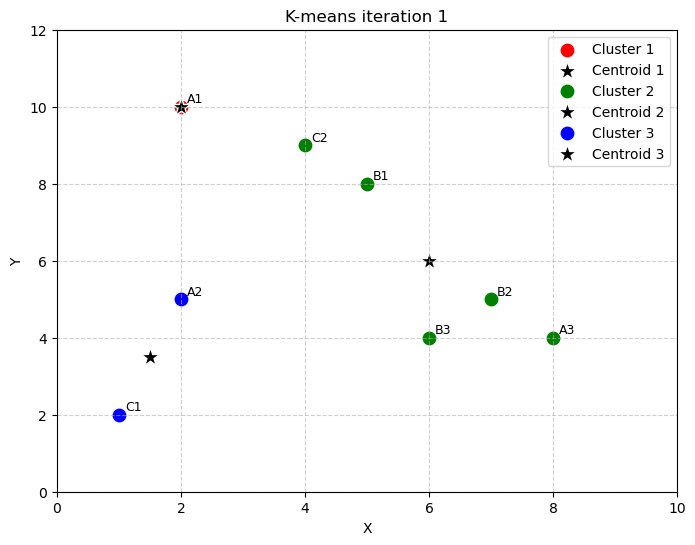

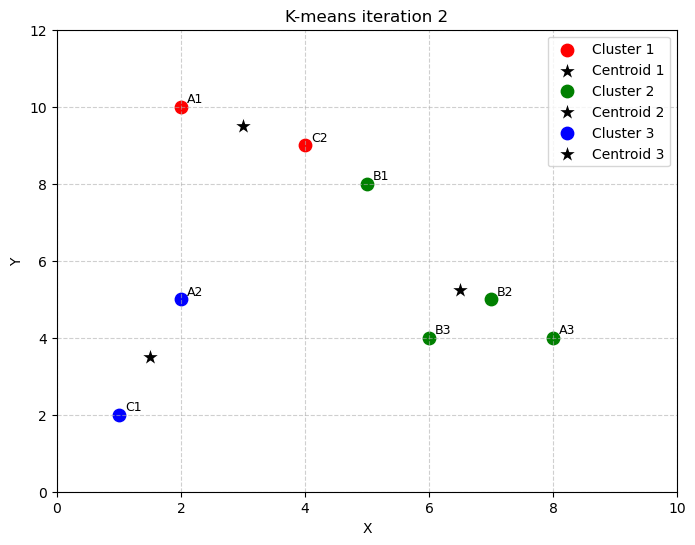

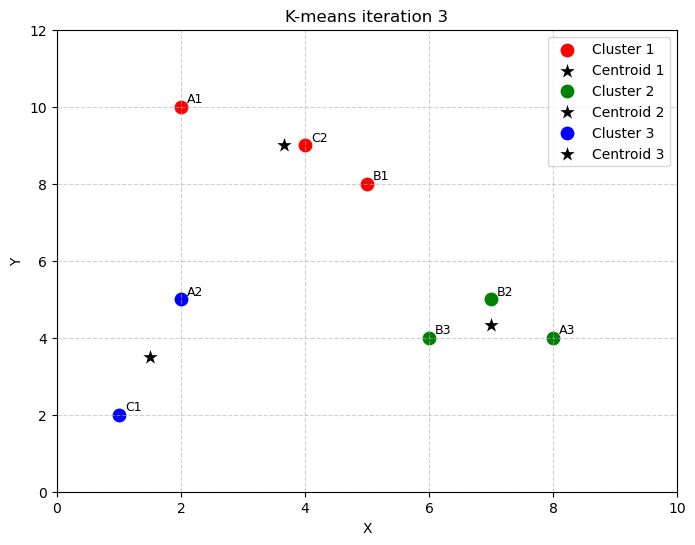


Converged after 4 iterations.

Final centroids:
Cluster 1: [3.66666667 9.        ]
Cluster 2: [7.         4.33333333]
Cluster 3: [1.5 3.5]

Final cluster assignments:
A1: Cluster 1
A2: Cluster 3
A3: Cluster 2
B1: Cluster 1
B2: Cluster 2
B3: Cluster 2
C1: Cluster 3
C2: Cluster 1


In [31]:
#Numerical-3 as per Note.
import numpy as np
import matplotlib.pyplot as plt

# Data points (coordinates) with labels
points = np.array([
    [2, 10],   # A1
    [2, 5],    # A2
    [8, 4],    # A3
    [5, 8],    # B1
    [7, 5],    # B2
    [6, 4],    # B3
    [1, 2],    # C1
    [4, 9]     # C2
])
labels = ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2']

# Initial centroids (A1, B1, C1) – indices 0, 3, 6
initial_indices = [0, 3, 6]
centroids = points[initial_indices].copy()

print("Initial centroids:")
for i, c in enumerate(centroids):
    print(f"Cluster {i+1}: {c}")

# Store history of centroids for plotting
centroid_history = [centroids.copy()]

max_iters = 10
tol = 1e-4

for iteration in range(max_iters):
    # ---------- Assignment step ----------
    # Compute distances from each point to each centroid
    distances = np.linalg.norm(points[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
    # Assign each point to the nearest centroid
    cluster_labels = np.argmin(distances, axis=1)
    
    # ---------- Update step ----------
    new_centroids = np.array([
        points[cluster_labels == k].mean(axis=0) if np.any(cluster_labels == k) else centroids[k]
        for k in range(len(centroids))
    ])
    
    # Check for convergence
    if np.allclose(centroids, new_centroids, atol=tol):
        print(f"\nConverged after {iteration+1} iterations.")
        break
    
    centroids = new_centroids
    centroid_history.append(centroids.copy())
    
    # ---------- Plot current iteration ----------
    plt.figure(figsize=(8, 6))
    colors = ['red', 'green', 'blue']
    for k in range(len(centroids)):
        # Points in this cluster
        cluster_points = points[cluster_labels == k]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                    color=colors[k], s=80, label=f'Cluster {k+1}')
        # Centroid
        plt.scatter(centroids[k, 0], centroids[k, 1],
                    marker='*', color='black', s=200, edgecolors='white',
                    label=f'Centroid {k+1}')
    
    # Annotate points with labels
    for i, (x, y) in enumerate(points):
        plt.text(x+0.1, y+0.1, labels[i], fontsize=9)
    
    plt.title(f'K-means iteration {iteration+1}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.xlim(0, 10)
    plt.ylim(0, 12)
    plt.show()

# ---------- Final result ----------
print("\nFinal centroids:")
for i, c in enumerate(centroids):
    print(f"Cluster {i+1}: {c}")

print("\nFinal cluster assignments:")
for i, label in enumerate(labels):
    print(f"{label}: Cluster {cluster_labels[i]+1}")

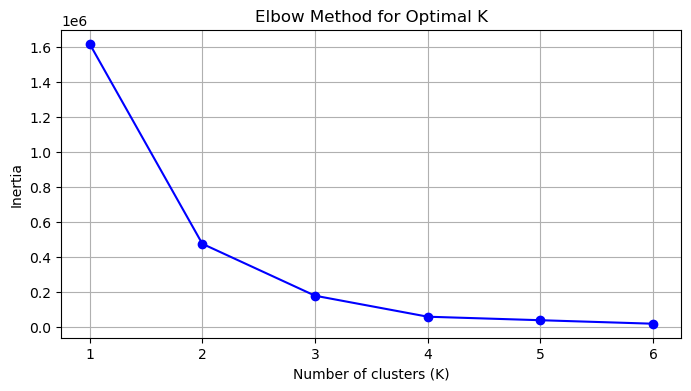


Based on the elbow curve, we choose K = 3

Initial centroids (randomly chosen from data points):
  Cluster 1: [ 20 500]
  Cluster 2: [  40 1000]
  Cluster 3: [  35 1400]


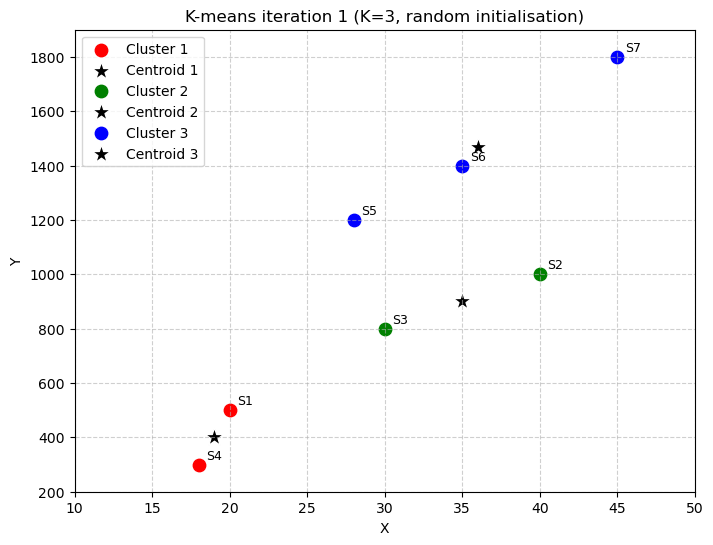


Converged after 2 iterations.

FINAL RESULTS

Final centroids:
  Cluster 1: [ 19. 400.]
  Cluster 2: [ 35. 900.]
  Cluster 3: [  36.         1466.66666667]

Final cluster assignments:
  S1: Cluster 1
  S2: Cluster 2
  S3: Cluster 2
  S4: Cluster 1
  S5: Cluster 3
  S6: Cluster 3
  S7: Cluster 3


In [33]:
#Numerical-1 (See Notes of ML)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ------------------------------
# 1. Data
# ------------------------------
points = np.array([
    [20, 500],   # S1
    [40, 1000],  # S2
    [30, 800],   # S3
    [18, 300],   # S4
    [28, 1200],  # S5
    [35, 1400],  # S6
    [45, 1800]   # S7
])
labels = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']

# ------------------------------
# 2. Elbow method to find optimal K
# ------------------------------
inertias = []
K_range = range(1, min(7, len(points)))  # test K from 1 to 6

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(points)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

# Choose K = 3 (the "elbow" is clear at K=3)
K = 3
print(f"\nBased on the elbow curve, we choose K = {K}\n")

# ------------------------------
# 3. Custom K-means with visualisation
# ------------------------------
# Initialise centroids randomly from the data (reproducible seed)
np.random.seed(42)
initial_indices = np.random.choice(len(points), K, replace=False)
centroids = points[initial_indices].copy()

print("Initial centroids (randomly chosen from data points):")
for i, c in enumerate(centroids):
    print(f"  Cluster {i+1}: {c}")

centroid_history = [centroids.copy()]
max_iters = 20
tol = 1e-4

for iteration in range(max_iters):
    # ---------- Assignment ----------
    distances = np.linalg.norm(points[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
    cluster_labels = np.argmin(distances, axis=1)
    
    # ---------- Update ----------
    new_centroids = np.array([
        points[cluster_labels == k].mean(axis=0) if np.any(cluster_labels == k) else centroids[k]
        for k in range(K)
    ])
    
    # Check convergence
    if np.allclose(centroids, new_centroids, atol=tol):
        print(f"\nConverged after {iteration+1} iterations.")
        centroids = new_centroids
        centroid_history.append(centroids.copy())
        break
    
    centroids = new_centroids
    centroid_history.append(centroids.copy())
    
    # ---------- Plot current iteration ----------
    plt.figure(figsize=(8, 6))
    colors = ['red', 'green', 'blue', 'purple', 'orange'][:K]
    
    for k in range(K):
        cluster_points = points[cluster_labels == k]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                    color=colors[k], s=80, label=f'Cluster {k+1}')
        plt.scatter(centroids[k, 0], centroids[k, 1],
                    marker='*', color='black', s=200, edgecolors='white',
                    label=f'Centroid {k+1}')
    
    # Annotate points with labels
    for i, (x, y) in enumerate(points):
        plt.text(x+0.5, y+20, labels[i], fontsize=9)
    
    plt.title(f'K-means iteration {iteration+1} (K={K}, random initialisation)')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.xlim(10, 50)
    plt.ylim(200, 1900)
    plt.show()

# ------------------------------
# 4. Final results
# ------------------------------
print("\n" + "="*40)
print("FINAL RESULTS")
print("="*40)
print("\nFinal centroids:")
for i, c in enumerate(centroids):
    print(f"  Cluster {i+1}: {c}")

print("\nFinal cluster assignments:")
for i, label in enumerate(labels):
    print(f"  {label}: Cluster {cluster_labels[i]+1}")